<a href="https://colab.research.google.com/github/40824226-sys/try_/blob/main/%E4%BD%9C%E5%93%813.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

第一階段:訓練路徑規劃（無人靜態地圖）...
第一階段:訓練完成！
第二階段:GoGoCar上路，AEB系統啟動
步數18：AEB自動緊急煞車系統觸發！檢測到碰撞風險，車子在(7,6)煞車等待
測試成功！車子順利抵達終點！總共步數:19


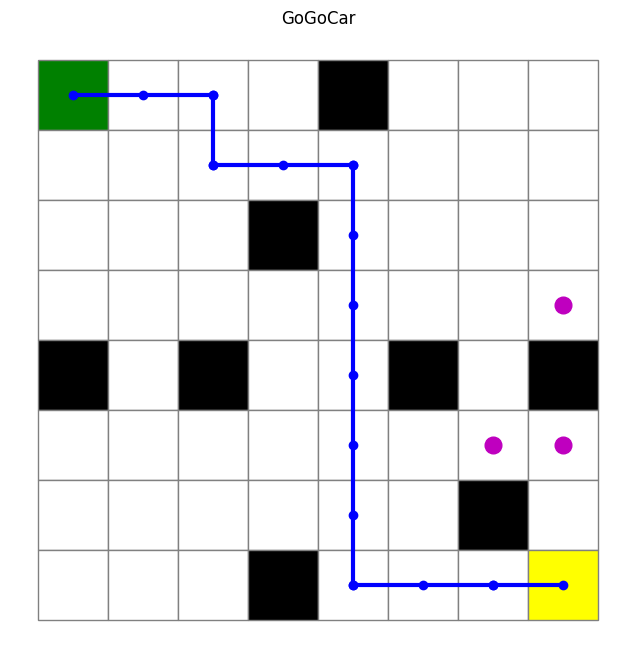

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

# 地圖:8*8  起點:S  障礙物:X (8) 終點:G
grid = [
    ['S','.','.','.','X','.','.','.'],
    ['.','.','.','.','.','.','.','.'],
    ['.','.','.','X','.','.','.','.'],
    ['.','.','.','.','.','.','.','.'],
    ['X','.','X','.','.','X','.','X'],
    ['.','.','.','.','.','.','.','.'],
    ['.','.','.','.','.','.','X','.'],
    ['.','.','.','X','.','.','.','G'],
]

n_rows , n_cols = len(grid) , len(grid)

dirs = ['N','E','S','W']
actions = ['F','L','R']
dirs_map = {'N':(-1,0),'E':(0,1),'S':(1,0),'W':(0,-1)}
turn_left = {'N':'W','E':'N','S':'E','W':'S'}
turn_right = {'N':'E','E':'S','S':'W','W':'N'}

# 初始化 Q 表
Q = { (r, c, d):{a: 0.0 for a in actions}
      for r in range(n_rows)
      for c in range(n_cols)
      for d in dirs
      if grid[r][c] != 'X' }

alpha = 0.1
gamma = 0.9
epsilon = 0.1
episodes = 3000

for r, row in enumerate(grid):
    for c, val in enumerate(row):
        if val == 'S': start = (r, c)
        if val == 'G': goal = (r, c)

print('第一階段:訓練路徑規劃（無人靜態地圖）...')
for i in range(episodes):
    r, c = start
    d = 'E'
    done = False

    while not done:
        state = (r, c, d)
        if random.random() < epsilon:
            action = random.choice(actions)
        else:
            action = max(Q[state], key=Q[state].get)

        nr, nc, nd = r, c, d
        if action == 'F':
            dr, dc = dirs_map[d]
            tr, tc = r + dr, c + dc
            if 0 <= tr < n_rows and 0 <= tc < n_cols and grid[tr][tc] != 'X':
                nr, nc = tr, tc
        elif action == 'L':
            nd = turn_left[d]
        elif action == 'R':
            nd = turn_right[d]

        # 靜態獎勵
        if (nr, nc) == goal:
            reward = 100
            done = True
        else:
            reward = -1

        next_state = (nr, nc, nd)
        best_next_q = max(Q[next_state].values())
        Q[state][action] += alpha * (reward + gamma * best_next_q - Q[state][action])
        r, c, d = nr, nc, nd

print('第一階段:訓練完成！')

# 行人物件
class Pedestrian:
    def __init__(self):
        self.reset()

    def reset(self):
        while True:
            self.r ,self.c = random.randint(0,n_rows-1) , random.randint(0,n_cols-1)

            if grid[self.r][self.c] == '.' and (self.r, self.c) != start and (self.r, self.c) != goal:
                break
        self.dr , self.dc = random.choice(list(dirs_map.values()))

    def move(self):
        nr , nc = self.r + self.dr ,  self.c + self.dc
        if 0 <= nr < n_rows and 0 <= nc < n_cols and grid[nr][nc] != 'X':
            self.r , self.c = nr , nc
        else:
            self.dr , self.dc = random.choice(list(dirs_map.values()))

# AEB自動緊急煞車系統
def is_unsafe_to_move(tr, tc, peds):
    for p in peds:
        # 狀況1：車子想去的目標格子現在就有行人
        if (p.r, p.c) == (tr, tc):
            return True
        # 狀況2：預判行人下一步也會走進車子的目標格子
        p_nr, p_nc = p.r + p.dr, p.c + p.dc
        if (p_nr, p_nc) == (tr, tc):
            return True
    return False

# 第二階段:動態上路測試
r, c = start
d = 'E'
path = [(r, c)]
test_peds = [Pedestrian() for _ in range(3)] # 放入3個行人

print("第二階段:GoGoCar上路，AEB系統啟動")
for i in range(80):
    state = (r, c, d)
    if state not in Q:
        break

    # 根據Q表選擇動作
    action = max(Q[state], key=Q[state].get)

    # 預測如果執行該動作，車子的下一位置會在哪裡
    expected_r, expected_c = r, c
    if action == 'F':
        dr, dc = dirs_map[d]
        expected_r, expected_c = r + dr, c + dc

    # 攔截檢查：不論前進或轉彎，只要位置有行人就煞車
    is_braking = False

    if is_unsafe_to_move(expected_r, expected_c, test_peds):
        print(f"步數{i+1}：AEB自動緊急煞車系統觸發！檢測到碰撞風險，車子在({r},{c})煞車等待")
        is_braking = True

    # 執行最終動作
    if is_braking:
        pass # 強制原地不動，保持原坐標與原方向
    else:
        if action == 'F':
            dr, dc = dirs_map[d]
            r, c = r + dr, c + dc
        elif action == 'L':
            d = turn_left[d]
        elif action == 'R':
            d = turn_right[d]

    # 車子做完決策後，環境中的行人移動
    for p in test_peds:
        p.move()

    path.append((r, c))
    if (r, c) == goal:
        print(f"測試成功！車子順利抵達終點！總共步數:{i+1}")
        break

# 繪製最終圖
fig, ax = plt.subplots(figsize=(8, 8))
for i in range(n_rows):
    for j in range(n_cols):
        color = 'white'
        if grid[i][j] == 'X': color = 'black'
        elif grid[i][j] == 'S': color = 'green'
        elif grid[i][j] == 'G': color = 'yellow'
        ax.add_patch(patches.Rectangle((j, n_rows-1-i), 1, 1, facecolor=color, edgecolor='gray'))

# 畫出車子歷史路徑（藍線）
px = [col + 0.5 for row, col in path]
py = [n_rows - 1 - row + 0.5 for row, col in path]
ax.plot(px, py, color='blue', linewidth=3, marker='o', label='GoGoCar Path')

# 畫出行人的最後位置（紫點）
for p in test_peds:
    ax.plot(p.c + 0.5, n_rows - 1 - p.r + 0.5, 'mo', markersize=12)

ax.set_aspect('equal')
plt.title("GoGoCar")
plt.axis('off')
plt.show()